Variant A.1.: 
Uses fixed features (from RND target net). The TD error is from the main value head prediction $\psi$

This version has:
- fixed features
- Aleatoric uncertainty in TD error
- non-stationary / bias estimate of TD error $\delta$ (RND signal)
But:
- does not use same features as the value weights

In [ ]:
from utils import *
config['TOTAL_TIMESTEPS'] = 100_000
config["NORMALIZE_OBS"] = True
config["NORMALIZE_REWARDS"] = False
config["REGULARIZATION"] = 0.1

# NOTE: this function is not differentiable w.r.t. the features but could easily be made so by passing in params, and performing inference.
def lstd_0_batch_update( 
                    lstd_state: Dict,
                    transitions: Explore_Transition,
                    features: jnp.ndarray,
                    next_features: jnp.ndarray,
                    config: Dict,
                    α: float, # ema coefficient
    ):
    "Updates LSTD matrices based on a batch of transitions; expects the features to be pre-computed"
    
    # --------- Per-sample methods ---------
    def lstd_0(features, next_features, transition):
        "Per-timestep LSTD(0) matrix update"
        td_features = features - config['GAMMA'] * (1 - transition.done) * next_features
        A_sample = jnp.outer(features, td_features)  # k x k; # A += z * [φ(s,a) - γ(1-done)E[φ(s',a')]]^T)
        b_sample = features * transition.reward  # k,
        return A_sample, b_sample
        
    def per_sample_OPG(features, td_error):
        "S = E[ (δ φ)(δ φ)^T ], the Outer-Product of Gradients, heteroskedastic gram matrix"
        return jnp.outer(features, features) * (td_error**2)
    # --------- end per-sample methods ---------
    
    # --------- LSTD Update ---------
    A, b, S, t = lstd_state['A'], lstd_state['b'], lstd_state['S'], lstd_state['t']
    batch_axes = tuple(range(transitions.done.ndim))
    N  = transitions.done.size
    
    batch_lstd_0 = jax.vmap(jax.vmap(lstd_0))
    A_update, b_update = batch_lstd_0(features, next_features, transitions)
    delta_normalized = transitions.td_error / (1e-6 + jnp.sqrt((transitions.td_error**2).mean()))
    S_update = jax.vmap(jax.vmap(per_sample_OPG))(features, transitions.td_error)
    # S_update = jax.vmap(jax.vmap(per_sample_OPG))(features, delta_normalized)    

    # batch averages
    A_b, b_b, S_b = jax.tree.map(lambda x: x.mean(axis=batch_axes), (A_update, b_update, S_update))
    
    # Add regularization
    A_b = A_b + config['PER_UPDATE_REGULARIZATION'] * jnp.eye(A.shape[0])  # Regularization for numerical stability
    # S_b = S_b + config['PER_UPDATE_REGULARIZATION'] * jnp.eye(A.shape[0])  # Regularization for numerical stability

    # EMA
    A_new = (1-α) * A + α * A_b
    b_new = (1-α) * b + α * b_b
    S_new = (1-α) * S + α * S_b
    
    # bias correction
    bc = 1.0 - (1.0 - α)**t
    bc = jnp.maximum(bc, 1e-6)
    A_new = A_new / bc
    b_new = b_new / bc
    S_new = S_new / bc
    
    # for symmetry of S
    S_new = 0.5 * (S_new + S_new.T)

    # effective sample size of EMA is 1/alpha
    A_inv = jnp.linalg.solve(A_new, jnp.eye(A.shape[0]))

    cov_w = α * (A_inv @ S_new @ A_inv.T)
    # EMA of weights
    w = A_inv @ b_new
    β = config['ema_coeff_w']
    w =  β * w + (1-β) * lstd_state['w']
    bc_w = jnp.maximum( (1- (1-β**t)) , 1e-6)
    w = w / bc_w
    
    N = N + lstd_state['N']
    return {'A': A_new, 'b': b_new, 'w': w, 'S': S_new, 'N': N, 't': t+1, 'Sandwich': cov_w, 'A_update': A_b, 'b_update': b_b, 'S_update': S_b}

def compute_sandwich(lstd_state: Dict, α = 1):
    "Computes the sandwich covariance from LSTD state"
    A, S = lstd_state['A'], lstd_state['S']
    A_inv = jnp.linalg.pinv(A)
    cov_w = α * A_inv @ S @ A_inv.T
    return cov_w

def make_train(config):
    def initialize_rnd_network(rng, obs_shape):
        rnd_network = RND_Net(activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        rnd_params = rnd_network.init(_rng, init_x)
        return rnd_network, rnd_params
    
    def initialize_network(n_actions, obs_shape, rng):
        network = Two_Head_ActorCritic(n_actions, activation=config["ACTIVATION"], normalize_value_features = config['NORMALIZE_FEATURES'])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)
        return network, network_params 
    
    batch_size = config["NUM_STEPS"] * config["NUM_ENVS"]
    config["NUM_MINIBATCHES"] = batch_size // config["MINIBATCH_SIZE"] # per epoch
    config["NUM_UPDATES"] = config["TOTAL_TIMESTEPS"] // batch_size
    total_grad_steps = config["NUM_UPDATES"] * config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"]
    
    env, env_params = gymnax.make(config["ENV_NAME"])
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)      # Log REAL returns (possibly sparse)

    if config["NORMALIZE_REWARDS"]:
        env = NormalizeRewardWrapper(env, gamma=config["GAMMA"]) # Normalize Rewards
    if config["NORMALIZE_OBS"]:
        env = NormalizeObservationWrapper(env) # Normalize Obs
    
    n_actions = env.action_space(env_params).n

    def train(rng):

        GET_ALPHA_FN = lambda t: jnp.maximum(1/10000, 1/t)
        # initialize rnd networks
        rnd_rng, rng = jax.random.split(rng)
        target_rng, rng = jax.random.split(rng)
        rnd_net, rnd_params = initialize_rnd_network(rnd_rng, env.observation_space(env_params).shape)
        _, target_params = initialize_rnd_network(target_rng, env.observation_space(env_params).shape)
        
        # initialize value and policy network
        network_rng, rng = jax.random.split(rng)
        network, network_params = initialize_network(n_actions, env.observation_space(env_params).shape, network_rng)
        # get_features_fn = lambda params, obs: train_state.apply_fn(params, obs, method="get_value_features")[0]

        dummy_obs = jnp.zeros(env.observation_space(env_params).shape)
        dummy_phi = network.apply(network_params, dummy_obs, method="get_value_features")[0]
        k = dummy_phi.shape[-1]

        initial_lstd_state = {
            'A': jnp.eye(k) * config['REGULARIZATION'],  # Regularization for numerical stability
            'b': jnp.zeros(k),
            'w': jnp.zeros(k),
            'S': jnp.eye(k),
            'N': 0, # number of samples
            't': 1, # number of updates
            'A_update': jnp.zeros((k, k)),
            'b_update': jnp.zeros(k),
            'S_update': jnp.zeros((k, k)),
        }
        initial_lstd_state['Sandwich']= compute_sandwich(initial_lstd_state)

        lr_scheduler = optax.linear_schedule(
            init_value=config["LR"],
            end_value=config["LR_END"],
            transition_steps=total_grad_steps
        )
        tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adamw(lr_scheduler, eps=1e-5),
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
        rnd_state = RNDTrainState.create(
            apply_fn=rnd_net.apply,
            params=rnd_params,
            tx=tx,
            target_params=target_params,
        )
        get_features_fn = lambda params, obs: rnd_net.apply(params, obs)
        batch_get_features = jax.vmap(get_features_fn, in_axes=(None, 0))
        
        get_v_features_fn = lambda params, obs: train_state.apply_fn(params, obs, method="get_value_features")[0]
        batch_get_v_features = jax.vmap(get_v_features_fn, in_axes=(None, 0))

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # WARMUP:
        def _warmup_step(runner_state, unused):
            env_state, last_obs, rng = runner_state
            
            # Select RANDOM actions (no need for network here, just exploring state space)
            rng, _rng = jax.random.split(rng)
            rng_action = jax.random.split(_rng, config["NUM_ENVS"])
            action = jax.vmap(env.action_space(env_params).sample)(rng_action)
            
            # Step env (wrappers will update their internal mean/std stats automatically)
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            
            return (env_state, obsv, rng), None

        # Run the warmup
        warmup_runner_state = (env_state, obsv, rng)
        (env_state, obsv, rng), _ = jax.lax.scan(
            _warmup_step, warmup_runner_state, None, config["WARMUP"]
        )
        # -------------------------

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            
            train_state, lstd_state, rnd_state, env_state, last_obs, rng, idx = runner_state
            
            # COLLECT TRAJECTORIES
            def _env_step(env_scan_state, unused):
                train_state, rnd_state, env_state, last_obs, rng= env_scan_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value, i_value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                # Record
                next_pi, next_value, next_i_value = network.apply(train_state.params, obsv)
                δ = reward + config['GAMMA'] * (1-done) * next_value - value
                
                # RND intrinsic reward:
                target_embedding = rnd_state.apply_fn(rnd_state.target_params, obsv) # should be N_ENVS x N_STEPS x k
                pred = rnd_state.apply_fn(rnd_state.params, obsv)
                cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embedding) # range from -1 to 1
                intrinsic_reward =  0.5 * (1.0 - cosine_sim) # should range from 0 to 1. most similar = 0, least similar = 1
                # ablation: use RND instead of the td-error
                # δ=jnp.sqrt(intrinsic_reward)
                # δ= jnp.ones_like(reward)
                transition = Explore_Transition(
                    done, action, value, i_value, reward, intrinsic_reward, log_prob, last_obs, obsv, target_embedding, δ, info
                )
                runner_state = (train_state, rnd_state, env_state, obsv, rng)
                return runner_state, transition
            
            env_step_state = (train_state, rnd_state, env_state, last_obs, rng)
            (_, _, env_state, last_obs, rng), traj_batch = jax.lax.scan(
                _env_step, env_step_state , None, config["NUM_STEPS"]
            )
            # COMPUTE BONUS:
            next_phi = batch_get_features(rnd_state.target_params, traj_batch.next_obs)
            Sandwich = lstd_state['Sandwich']
            
            # Einstein summation for quadratic form x^T M x
            # '...i' : batch of features phi (... x k)
            # 'ij'   : Sandwich matrix (k x k)
            # '...j' : batch of features phi again (... x k)
            # '...'  : output is just the batch dimensions (N)
            variance_per_state = jnp.einsum('...i,ij,...j->...', next_phi, Sandwich, next_phi)
            U_prime = config['BONUS_SCALE'] * jnp.sqrt(jnp.maximum(variance_per_state, 1e-6))
            # CALCULATE ADVANTAGE
            _, last_val, _ = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            gae, targets = _calculate_gae(traj_batch, last_val)
            # optimistic advantage! the next state value is uncertainty - so we add a bonus proportional to its stddev
            advantages = gae + config['GAMMA'] * U_prime * (1 - traj_batch.done)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                
                def _update_minbatch(minibatch_input, batch_info):
                    train_state, rnd_state, mask_rng = minibatch_input
                    traj_batch, advantages, targets = batch_info
                    
                    def rnd_loss_fn(rnd_params, target_embeddings, mask):
                        # RERUN NETWORK
                        pred = rnd_net.apply(rnd_params, traj_batch.obs)
                        cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embeddings)
                        losses = -cosine_sim
                        loss = (losses * mask).sum() / (mask.sum() + 1e-8)
                        return loss, _

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value, i_val = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)
                        
                        # VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )
                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)
                    # end loss_fn

                    # --- UPDATE PPO ---
                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    
                    (total_loss, _), grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    
                    # --- UPDATE RND ---
                    rnd_grad_fn = jax.value_and_grad(rnd_loss_fn, has_aux=True)
                    # mask fraction of the data
                    mask = jax.random.bernoulli(mask_rng, p=config['RND_TRAIN_FRAC'], shape=(traj_batch.obs.shape[0],))
                    (rnd_loss, _), rnd_grads = rnd_grad_fn(rnd_state.params, traj_batch.embedding, mask)
                    rnd_state = rnd_state.apply_gradients(grads=rnd_grads)
                    return (train_state, rnd_state, mask_rng), (total_loss, rnd_loss)
                # end update_minibatch

                train_state, rnd_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                rng, mask_rng = jax.random.split(rng)
                (train_state, rnd_state, mask_rng), total_loss = jax.lax.scan(
                    _update_minbatch, (train_state, rnd_state, mask_rng), minibatches
                )
                update_state = (train_state, rnd_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss
            # end update_epoch

            # --------- Train the network ---------
            update_state = (train_state, rnd_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["NUM_EPOCHS"]
            )
            train_state, rnd_state, _, _, _, rng = update_state
            # -------------------------------
            # --------- Update LSTD ---------
            new_phi = batch_get_features(rnd_state.target_params, traj_batch.obs)
            new_phi_prime = batch_get_features(rnd_state.target_params, traj_batch.next_obs)
            lstd_state = lstd_0_batch_update(
                lstd_state,
                traj_batch,
                new_phi,
                new_phi_prime,
                config,
                α=GET_ALPHA_FN(lstd_state['t']),
            )
            # -------------------------------
            # --------- Update metrics ------
            metric = {k: v.mean() for k, v in traj_batch.info.items()} # performance
            
            v_features = batch_get_v_features(train_state.params, traj_batch.next_obs)
            v_feat_norm = jnp.linalg.norm(v_features, axis=-1).mean()
            v_feat_norm_std = jnp.linalg.norm(v_features, axis=-1).std()
            feat_norm = jnp.linalg.norm(next_phi, axis=-1).mean()
            feat_norm_std = jnp.linalg.norm(next_phi, axis=-1).std()

            # constant obs:
            constant_obs = jnp.zeros_like(traj_batch.obs) + 0.1
            target_features_const_obs = rnd_net.apply(rnd_state.target_params, constant_obs)
            avg_targ_feat_const_obs = jnp.linalg.norm(target_features_const_obs,axis=-1).mean()

            # 2. Bonus Statistics
            bonus_mean = U_prime.mean()
            bonus_max = U_prime.max()
            bonus_std = U_prime.std()
            implied_count = 1.0 / (jnp.square(U_prime).mean() + 1e-8)

            gae_mean = gae.mean()
            gae_std = gae.std()
            gae_max = gae.max()

            lambda_ret_mean = targets.mean()
            lambda_ret_std = targets.std()

            td_error_mean = traj_batch.td_error.mean()
            td_error_std = traj_batch.td_error.std()

            intrinsic_rew_mean = traj_batch.intrinsic_reward.mean()
            intrinsic_rew_std = traj_batch.intrinsic_reward.std()
            target_embed_mean = jnp.linalg.norm(traj_batch.embedding).mean()
            target_embed_std = jnp.linalg.norm(traj_batch.embedding).std()
            mean_state = traj_batch.obs.mean(0).mean(0) # shape: (obs_shape)
            mean_rew = traj_batch.reward.mean()
            metric.update({
                "ppo_loss": loss_info[0], 
                "rnd_loss": loss_info[1],
                "mean_x": mean_state[0],
                "mean_v": mean_state[1],
                "v_feat_norm": v_feat_norm,
                "v_feat_norm_std": v_feat_norm_std,
                "feat_norm_std": feat_norm_std,
                "feat_norm": feat_norm,
                "feat_norm": feat_norm,
                "bonus_mean": bonus_mean,
                "bonus_std": bonus_std,
                "bonus_max": bonus_max,
                "implied_count": implied_count,
                "gae_mean": gae_mean,
                "gae_std": gae_std,
                "gae_max": gae_max,
                "lambda_ret_mean": lambda_ret_mean,
                "lambda_ret_std": lambda_ret_std,
                "td_error_mean":td_error_mean,
                "td_error_std": td_error_std,
                "intrinsic_rew_mean": intrinsic_rew_mean,
                "intrinsic_rew_std": intrinsic_rew_std,
                "target_embed_mean": target_embed_mean,
                "target_embed_std": target_embed_std,
                "avg_targ_feat_const_obs": avg_targ_feat_const_obs,
                "mean_rew": mean_rew,
            })
            runner_state = (train_state, lstd_state, rnd_state, env_state, last_obs, rng, idx+1)
            return runner_state, metric
            # end update_step

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, initial_lstd_state, rnd_state, env_state, obsv, _rng, 0)
        runner_state, metrics = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metrics}

    return train


In [2]:
import time
import matplotlib.pyplot as plt
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, 4)
train_vjit = jax.jit(jax.vmap(make_train(config)))
t0 = time.time()
outs = jax.block_until_ready(train_vjit(rngs))
print(f"time: {time.time() - t0:.2f} s")

for i in range(4):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.show()

ValueError: SparseMountainCar-v0 is not in registered gymnax environments.

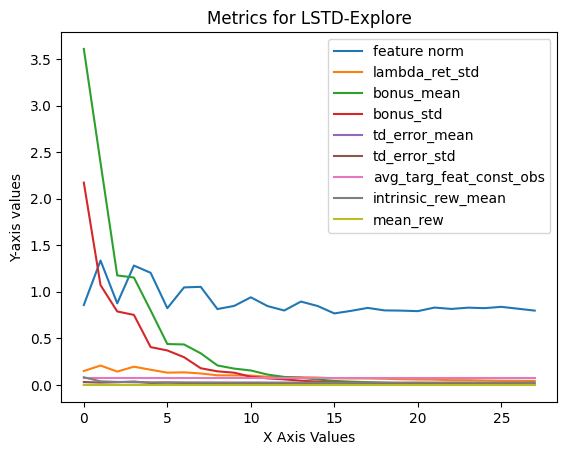

In [5]:
starting_point = 1
plt.plot(outs["metrics"]["feat_norm"][0][starting_point:], label = 'feature norm')
# plt.plot(outs["metrics"]["feat_norm_std"][0][starting_point:], label = 'feature std')
# plt.plot(outs["metrics"]["v_feat_norm"][0][starting_point:], label = 'v feature norm')
# plt.plot(outs["metrics"]["v_feat_norm_std"][0][starting_point:], label = 'v feature std')
# plt.plot(outs["metrics"]["lambda_ret_mean"][0][starting_point:], label = 'lambda_ret_mean')
plt.plot(outs["metrics"]["lambda_ret_std"][0][starting_point:], label = 'lambda_ret_std')
plt.plot(outs["metrics"]["bonus_mean"][0][starting_point:], label = 'bonus_mean')
plt.plot(outs["metrics"]["bonus_std"][0][starting_point:], label = 'bonus_std')
plt.plot(outs["metrics"]["td_error_mean"][0][starting_point:], label = 'td_error_mean')
plt.plot(outs["metrics"]["td_error_std"][0][starting_point:], label = 'td_error_std')
plt.plot(outs["metrics"]["avg_targ_feat_const_obs"][0][starting_point:], label = 'avg_targ_feat_const_obs')
plt.plot(outs["metrics"]["intrinsic_rew_mean"][0][starting_point:], label = 'intrinsic_rew_mean')
plt.plot(outs["metrics"]["mean_rew"][0][starting_point:], label = 'mean_rew')

# plt.plot(outs["metrics"]["target_embed_mean"].mean(0)[starting_point:], label = 'target_embed_mean')

# Add labels and a title for clarity
plt.xlabel('X Axis Values')
plt.ylabel('Y-axis values')
plt.title('Metrics for LSTD-Explore')
plt.legend()

# Display the plot

# plt.savefig('LSTD_Metrics.pdf', bbox_inches='tight')
plt.show()

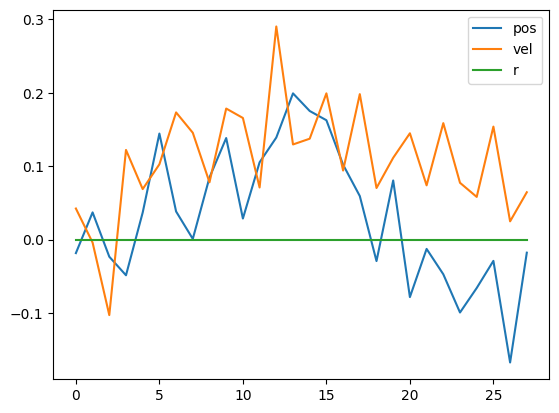

In [6]:
plt.plot(outs["metrics"]["mean_x"][0][starting_point:], label = 'pos')
plt.plot(outs["metrics"]["mean_v"][0][starting_point:], label = 'vel')
plt.plot(outs["metrics"]["mean_rew"][0][starting_point:], label = 'r')
plt.legend()

In [7]:
outs["metrics"]["mean_rew"]

Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],      dtype=float32)